# TCN(Temporal Convolutional Network) 실습 — Adding Problem

이 노트북에서는 **TCN(Temporal Convolutional Network)**을 직접 구현하고,  
고전적인 시계열 실험인 **Adding Problem**을 통해 TCN이 긴 시퀀스에서 필요한 정보를 어떻게 찾아내는지 실습합니다.

## 학습 목표

1. `Conv1d` 기반의 TCN 구조 이해
2. `Dilated Convolution`이 왜 필요한지 이해
3. `Residual Connection`의 역할 이해
4. `Chomp1d`가 왜 필요한지 이해
5. TCN의 **Receptive Field** 계산
6. Adding Problem 데이터 생성 과정 이해
7. MSE Loss를 이용한 회귀 학습
8. Train/Test 결과와 예측값을 직접 확인

> **중요:** PyTorch의 `Conv1d` 입력 형태는 `[Batch, Channel, Length]`입니다.


## 1. Adding Problem이란?

길이가 200인 시퀀스가 있다고 가정합니다.

- 첫 번째 채널: `0~1` 사이의 랜덤 값
- 두 번째 채널: 두 위치만 `1`, 나머지는 `0`
- 정답: 두 번째 채널에서 `1`인 위치에 해당하는 첫 번째 채널 값 두 개의 합

예를 들어,

```text
값 채널     : 0.2  0.7  0.3  0.9  0.4 ...
Indicator   :  0    1    0    0    1   ...

정답 = 0.7 + 0.4 = 1.1
```

즉 모델은 **200개의 시점 전체를 입력으로 받아서, Indicator가 가리키는 두 위치의 값을 찾아 더해야 합니다.**

따라서 단순히 가까운 시점만 보는 모델보다 **긴 시간 범위의 정보를 한 번에 볼 수 있는 구조**가 중요합니다.


In [2]:
# 필요한 라이브러리 불러오기

import torch
import torch.nn as nn
from torch.nn.utils import weight_norm
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import numpy as np
import matplotlib.pyplot as plt

# 재현 가능한 실험을 위해 난수 seed 고정
torch.manual_seed(42)
np.random.seed(42)

# GPU가 있으면 GPU 사용
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)


Using device: cuda


## 2. TCN의 핵심 아이디어

TCN은 일반적인 RNN처럼 데이터를 한 시점씩 순차적으로 처리하지 않고, **1D Convolution을 시간축에 적용**합니다.

TCN에서 중요한 개념은 다음 4가지입니다.

### ① Causal Convolution

현재 시점의 출력이 미래 시점의 데이터를 보면 안 됩니다.

```text
과거 ───────── 현재 ── 미래
  O     O      O       X
```

### ② Dilated Convolution

Convolution 필터 사이에 간격을 두어 더 넓은 시간 범위를 봅니다.

```text
dilation = 1 : O O O
dilation = 2 : O . O . O
dilation = 4 : O . . . O . . . O
```

### ③ Residual Connection

입력을 그대로 우회시켜 다음과 같이 더합니다.

```text
x ───────────────┐
                 + → ReLU
x → TCN block ───┘
```

깊은 네트워크에서도 gradient가 잘 전달되도록 도와줍니다.

### ④ Receptive Field

현재 출력 하나가 입력 시퀀스의 **얼마나 넓은 범위를 볼 수 있는지**를 의미합니다.

Adding Problem의 길이가 200이므로 최소한 충분히 큰 Receptive Field가 필요합니다.


## 3. Chomp1d

`Conv1d`에서 padding을 사용하면 출력 길이를 유지할 수 있지만, 단순한 padding 방식에서는 미래 시점의 정보가 포함될 수 있습니다.

TCN에서는 convolution 후 오른쪽 부분을 잘라내어 **causal convolution**을 만듭니다.

예:

```text
Conv 출력
[ t1, t2, t3, t4, t5, PAD ]

Chomp
[ t1, t2, t3, t4, t5 ]
```

즉 `Chomp1d`는 오른쪽 padding을 제거하는 역할입니다.


In [3]:
class Chomp1d(nn.Module):
    """
    Causal Convolution을 만들기 위해 오른쪽 padding을 제거하는 모듈.

    입력:
        x.shape = [Batch, Channel, Length]

    동작:
        마지막 chomp_size개의 time step을 제거합니다.
    """

    def __init__(self, chomp_size):
        super().__init__()

        # 제거할 time step의 개수
        self.chomp_size = chomp_size

    def forward(self, x):
        # 마지막 chomp_size만큼 잘라냅니다.
        #
        # 예:
        # x.shape = [64, 24, 204]
        # chomp_size = 4
        #
        # 결과:
        # [64, 24, 200]
        return x[:, :, :-self.chomp_size].contiguous()


## 4. TemporalBlock

TCN의 기본 building block입니다.

하나의 TemporalBlock은 다음과 같은 구조입니다.

```text
Input
  │
  ├── Conv1d
  ├── Chomp1d
  ├── ReLU
  ├── Dropout
  │
  ├── Conv1d
  ├── Chomp1d
  ├── ReLU
  ├── Dropout
  │
  └── Output
        +
      Residual
        │
      ReLU
```

여기서 두 개의 convolution을 사용하는 것이 중요합니다.

또한 입력 채널 수와 출력 채널 수가 다르면 `1x1 Conv`를 이용하여 residual의 channel 수를 맞춥니다.


In [4]:
class TemporalBlock(nn.Module):
    """
    TCN의 기본적인 residual block.

    Parameters
    ----------
    n_inputs : int
        입력 channel 수

    n_outputs : int
        출력 channel 수

    kernel_size : int
        convolution filter의 시간축 크기

    stride : int
        convolution stride

    dilation : int
        dilation 간격

    padding : int
        convolution에 사용할 padding

    dropout : float
        dropout 비율
    """

    def __init__(
        self,
        n_inputs,
        n_outputs,
        kernel_size,
        stride,
        dilation,
        padding,
        dropout=0.2
    ):
        super().__init__()

        # --------------------------------------------------
        # 첫 번째 dilated convolution
        # --------------------------------------------------
        #
        # weight_norm:
        # convolution weight를 정규화하여 학습을 안정화하는 데 도움
        #
        # Conv1d 입력:
        # [Batch, Channel, Time]
        #
        # 출력:
        # [Batch, n_outputs, Time]
        self.conv1 = weight_norm(
            nn.Conv1d(
                n_inputs,
                n_outputs,
                kernel_size,
                stride=stride,
                padding=padding,
                dilation=dilation
            )
        )

        # 오른쪽 padding 제거
        self.chomp1 = Chomp1d(padding)

        # 비선형 활성화 함수
        self.relu1 = nn.ReLU()

        # 과적합 방지를 위한 dropout
        self.dropout1 = nn.Dropout(dropout)

        # --------------------------------------------------
        # 두 번째 dilated convolution
        # --------------------------------------------------
        self.conv2 = weight_norm(
            nn.Conv1d(
                n_outputs,
                n_outputs,
                kernel_size,
                stride=stride,
                padding=padding,
                dilation=dilation
            )
        )

        self.chomp2 = Chomp1d(padding)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout)

        # 두 개의 convolution을 순서대로 연결
        self.net = nn.Sequential(
            self.conv1,
            self.chomp1,
            self.relu1,
            self.dropout1,
            self.conv2,
            self.chomp2,
            self.relu2,
            self.dropout2
        )

        # --------------------------------------------------
        # Residual branch
        # --------------------------------------------------
        #
        # 입력/출력 channel 수가 같으면 입력을 그대로 사용
        #
        # 예:
        # input  = [B, 24, T]
        # output = [B, 24, T]
        #
        # → 별도의 convolution 불필요
        #
        # 반대로 channel 수가 다르면 1x1 convolution으로
        # channel 수를 맞춥니다.
        self.downsample = (
            nn.Conv1d(n_inputs, n_outputs, 1)
            if n_inputs != n_outputs
            else None
        )

        # residual addition 이후 사용하는 활성화 함수
        self.relu = nn.ReLU()

        # weight 초기화
        self.init_weights()

    def init_weights(self):
        """Convolution weight를 작은 정규분포로 초기화."""

        self.conv1.weight.data.normal_(0, 0.01)
        self.conv2.weight.data.normal_(0, 0.01)

        if self.downsample is not None:
            self.downsample.weight.data.normal_(0, 0.01)

    def forward(self, x):
        # Main branch
        out = self.net(x)

        # Residual branch
        if self.downsample is None:
            res = x
        else:
            res = self.downsample(x)

        # Main branch + Residual branch
        return self.relu(out + res)


## 5. TemporalConvNet

여러 개의 `TemporalBlock`을 쌓아서 전체 TCN을 구성합니다.

핵심은 **dilation을 1, 2, 4, 8, ... 형태로 증가시키는 것**입니다.

예를 들어 8개의 block을 사용하면:

```text
Block 1 → dilation = 1
Block 2 → dilation = 2
Block 3 → dilation = 4
Block 4 → dilation = 8
Block 5 → dilation = 16
Block 6 → dilation = 32
Block 7 → dilation = 64
Block 8 → dilation = 128
```

이렇게 하면 네트워크가 깊어질수록 훨씬 넓은 시간 범위의 정보를 볼 수 있습니다.


In [5]:
class TemporalConvNet(nn.Module):
    """
    여러 개의 TemporalBlock을 쌓은 전체 TCN.

    num_channels 예:
        [24, 24, 24, 24]

    → TemporalBlock 4개 생성
    """

    def __init__(
        self,
        num_inputs,
        num_channels,
        kernel_size=2,
        dropout=0.2
    ):
        super().__init__()

        layers = []

        # block의 개수
        num_levels = len(num_channels)

        for i in range(num_levels):

            # dilation은 1, 2, 4, 8, ...으로 증가
            dilation_size = 2 ** i

            # 첫 번째 block은 원래 input channel을 사용
            #
            # 이후 block은 이전 block의 output channel을 입력으로 사용
            in_channels = (
                num_inputs
                if i == 0
                else num_channels[i - 1]
            )

            # 현재 block의 output channel
            out_channels = num_channels[i]

            # causal convolution을 위한 padding
            #
            # padding = (kernel_size - 1) * dilation
            padding = (kernel_size - 1) * dilation_size

            layers.append(
                TemporalBlock(
                    in_channels,
                    out_channels,
                    kernel_size,
                    stride=1,
                    dilation=dilation_size,
                    padding=padding,
                    dropout=dropout
                )
            )

        # 모든 TemporalBlock을 순차적으로 연결
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)


## 6. 최종 TCN 모델

전체 구조는 다음과 같습니다.

```text
Input
[Batch, 2, 200]
      │
      ▼
Temporal Conv Block × 8
      │
      ▼
[Batch, 24, 200]
      │
      ▼
마지막 time step 선택
[Batch, 24]
      │
      ▼
Linear
      │
      ▼
[Batch, 1]
```

Adding Problem은 **분류 문제가 아니라 회귀 문제**입니다.

따라서 마지막에 `softmax`나 `log_softmax`를 사용하지 않고, Linear layer의 값을 그대로 출력합니다.


In [6]:
class TCN(nn.Module):
    """
    최종 TCN 회귀 모델.

    input_size:
        입력 feature/channel 수

    output_size:
        출력 크기

    num_channels:
        각 TCN block의 channel 수

    kernel_size:
        convolution kernel 크기

    dropout:
        dropout 비율
    """

    def __init__(
        self,
        input_size,
        output_size,
        num_channels,
        kernel_size,
        dropout
    ):
        super().__init__()

        # 여러 TemporalBlock으로 구성된 TCN
        self.tcn = TemporalConvNet(
            input_size,
            num_channels,
            kernel_size=kernel_size,
            dropout=dropout
        )

        # 마지막 channel을 원하는 출력 크기로 변환
        self.linear = nn.Linear(
            num_channels[-1],
            output_size
        )

    def forward(self, inputs):

        # TCN 통과
        #
        # inputs:
        # [Batch, 2, 200]
        #
        # y1:
        # [Batch, 24, 200]
        y1 = self.tcn(inputs)

        # 마지막 time step만 사용
        #
        # y1[:, :, -1]
        # → [Batch, 24]
        #
        # 마지막 time step에는 전체 receptive field를 통해
        # 과거 시점의 정보가 반영되어 있습니다.
        last_step = y1[:, :, -1]

        # Linear layer를 통해 최종 합을 예측
        #
        # [Batch, 24] → [Batch, 1]
        output = self.linear(last_step)

        # 회귀 문제이므로 activation 없이 그대로 반환
        return output


## 7. Receptive Field 계산

TCN에서 매우 중요한 개념입니다.

`kernel_size=3`일 때 하나의 convolution은 dilation에 따라 다음 범위를 봅니다.

```text
dilation=1 → 3개 시점
dilation=2 → 5개 시점
dilation=4 → 9개 시점
...
```

stride가 1이고 kernel size가 `K`일 때,

**Receptive Field = 1 + (K - 1) × Σ dilation**

입니다.

현재 모델은 dilation이

`1, 2, 4, 8, 16, 32, 64, 128`

이고 각 block에 convolution이 2개씩 있으므로 충분히 긴 시간 범위를 볼 수 있습니다.


In [7]:
# 현재 TCN의 receptive field를 계산해 봅니다.

def calculate_receptive_field(
    num_levels,
    kernel_size,
    convs_per_block=2
):
    """
    stride=1인 TCN의 receptive field 계산.

    각 block에서 같은 dilation을 사용하는
    convolution이 convs_per_block개 있다고 가정합니다.
    """

    receptive_field = 1

    for i in range(num_levels):

        dilation = 2 ** i

        # convolution 하나가 추가하는 receptive field
        receptive_field += (
            (kernel_size - 1)
            * dilation
            * convs_per_block
        )

    return receptive_field


rf = calculate_receptive_field(
    num_levels=8,
    kernel_size=3,
    convs_per_block=2
)

print("TCN Receptive Field:", rf)
print("Adding Problem Sequence Length:", 200)

if rf >= 200:
    print("→ 전체 200개 시점을 충분히 볼 수 있습니다.")
else:
    print("→ Receptive Field가 부족합니다.")


TCN Receptive Field: 1021
Adding Problem Sequence Length: 200
→ 전체 200개 시점을 충분히 볼 수 있습니다.


## 8. Adding Problem 데이터 생성

각 샘플은 다음 형태입니다.

```text
X.shape = [2, 200]

Channel 0:
[0.13, 0.72, 0.44, ..., 0.31]

Channel 1:
[0,    1,    0,   ..., 0]
```

Channel 1에서 `1`인 위치를 찾고, 그 위치의 Channel 0 값을 더하면 정답입니다.


In [8]:
def generate_adding_problem(num_samples, seq_len):
    """
    Adding Problem 데이터셋 생성.

    Parameters
    ----------
    num_samples : int
        생성할 샘플 수

    seq_len : int
        시퀀스 길이

    Returns
    -------
    X : torch.FloatTensor
        [num_samples, 2, seq_len]

    Y : torch.FloatTensor
        [num_samples, 1]
    """

    # --------------------------------------------------
    # X
    #
    # channel 0 = 랜덤 값
    # channel 1 = 더해야 할 위치를 표시하는 indicator
    # --------------------------------------------------
    X = np.zeros(
        (num_samples, 2, seq_len)
    )

    # 회귀 target
    Y = np.zeros(
        (num_samples, 1)
    )

    for i in range(num_samples):

        # Channel 0:
        # 0~1 사이의 랜덤한 실수
        X[i, 0, :] = np.random.uniform(
            0,
            1,
            seq_len
        )

        # --------------------------------------------------
        # Channel 1:
        # 서로 다른 두 위치를 선택
        # --------------------------------------------------
        indices = np.random.choice(
            seq_len,
            2,
            replace=False
        )

        # 선택된 두 위치를 1로 표시
        X[i, 1, indices] = 1.0

        # --------------------------------------------------
        # Target 계산
        # --------------------------------------------------
        Y[i, 0] = (
            X[i, 0, indices[0]]
            + X[i, 0, indices[1]]
        )

    # NumPy → PyTorch Tensor
    X = torch.tensor(
        X,
        dtype=torch.float32
    )

    Y = torch.tensor(
        Y,
        dtype=torch.float32
    )

    return X, Y


In [9]:
# 데이터 생성

seq_length = 200

n_train = 10000
n_test = 2000

X_train, Y_train = generate_adding_problem(
    n_train,
    seq_length
)

X_test, Y_test = generate_adding_problem(
    n_test,
    seq_length
)

print("X_train:", X_train.shape)
print("Y_train:", Y_train.shape)
print("X_test :", X_test.shape)
print("Y_test :", Y_test.shape)


X_train: torch.Size([10000, 2, 200])
Y_train: torch.Size([10000, 1])
X_test : torch.Size([2000, 2, 200])
Y_test : torch.Size([2000, 1])


In [10]:
# 데이터 샘플 하나 확인

sample_idx = 0

values = X_train[sample_idx, 0]
indicator = X_train[sample_idx, 1]
target = Y_train[sample_idx, 0]

# Indicator가 1인 위치 찾기
positions = torch.where(indicator == 1)[0]

print("더해야 할 위치:", positions.tolist())

for pos in positions:
    print(
        f"index={pos.item():3d}, "
        f"value={values[pos].item():.4f}"
    )

print("실제 정답:", target.item())
print(
    "직접 계산:",
    values[positions[0]].item()
    + values[positions[1]].item()
)


더해야 할 위치: [55, 78]
index= 55, value=0.9219
index= 78, value=0.3585
실제 정답: 1.2803399562835693
직접 계산: 1.2803399562835693


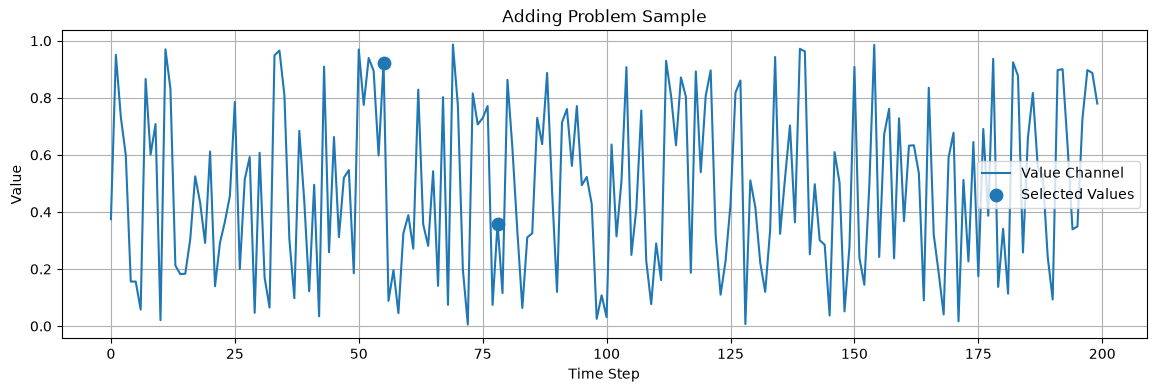

In [11]:
# 한 샘플을 시각화

plt.figure(figsize=(14, 4))

plt.plot(
    values.numpy(),
    label="Value Channel"
)

plt.scatter(
    positions.numpy(),
    values[positions].numpy(),
    s=80,
    label="Selected Values"
)

plt.title("Adding Problem Sample")
plt.xlabel("Time Step")
plt.ylabel("Value")

plt.legend()
plt.grid(True)

plt.show()


## 9. DataLoader 구성

PyTorch에서는 전체 데이터를 한 번에 모델에 넣기보다 **mini-batch** 단위로 학습합니다.

예를 들어 `batch_size=64`라면:

```text
X_train
10,000 samples

        ↓ DataLoader

[64, 2, 200]
[64, 2, 200]
[64, 2, 200]
...
```

`shuffle=True`를 사용하면 epoch마다 학습 데이터의 순서를 섞습니다.


In [12]:
batch_size = 64

train_loader = DataLoader(
    TensorDataset(X_train, Y_train),
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    TensorDataset(X_test, Y_test),
    batch_size=batch_size,
    shuffle=False
)

# 첫 번째 batch 확인
sample_batch, target_batch = next(iter(train_loader))

print("Batch input :", sample_batch.shape)
print("Batch target:", target_batch.shape)


Batch input : torch.Size([64, 2, 200])
Batch target: torch.Size([64, 1])


## 10. 모델 및 학습 설정

현재 설정:

| 항목 | 값 |
|---|---:|
| Input channels | 2 |
| Output size | 1 |
| Sequence length | 200 |
| TCN channels | 24 × 8 |
| Kernel size | 3 |
| Dropout | 0.0 |
| Epochs | 100 |
| Learning rate | 0.002 |
| Batch size | 64 |
| Loss | MSE |

Adding Problem은 회귀 문제이므로 `MSELoss`를 사용합니다.

```text
MSE = (실제값 - 예측값)²의 평균
```


In [13]:
# 하이퍼파라미터

input_channels = 2
output_size = 1

# 8개의 TemporalBlock
num_channels = [
    24, 24, 24, 24,
    24, 24, 24, 24
]

kernel_size = 3
dropout = 0.0

epochs = 100
lr = 2e-3

# 모델 생성
model = TCN(
    input_size=input_channels,
    output_size=output_size,
    num_channels=num_channels,
    kernel_size=kernel_size,
    dropout=dropout
).to(device)

# Adam optimizer
optimizer = optim.Adam(
    model.parameters(),
    lr=lr
)

# 회귀 문제용 Mean Squared Error
criterion = nn.MSELoss()

print(model)


C:\Users\loveiori\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\torch\nn\utils\weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


TCN(
  (tcn): TemporalConvNet(
    (network): Sequential(
      (0): TemporalBlock(
        (conv1): Conv1d(2, 24, kernel_size=(3,), stride=(1,), padding=(2,))
        (chomp1): Chomp1d()
        (relu1): ReLU()
        (dropout1): Dropout(p=0.0, inplace=False)
        (conv2): Conv1d(24, 24, kernel_size=(3,), stride=(1,), padding=(2,))
        (chomp2): Chomp1d()
        (relu2): ReLU()
        (dropout2): Dropout(p=0.0, inplace=False)
        (net): Sequential(
          (0): Conv1d(2, 24, kernel_size=(3,), stride=(1,), padding=(2,))
          (1): Chomp1d()
          (2): ReLU()
          (3): Dropout(p=0.0, inplace=False)
          (4): Conv1d(24, 24, kernel_size=(3,), stride=(1,), padding=(2,))
          (5): Chomp1d()
          (6): ReLU()
          (7): Dropout(p=0.0, inplace=False)
        )
        (downsample): Conv1d(2, 24, kernel_size=(1,), stride=(1,))
        (relu): ReLU()
      )
      (1): TemporalBlock(
        (conv1): Conv1d(24, 24, kernel_size=(3,), stride=(1,), pa

In [14]:
# 전체 parameter 개수 확인

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"Total parameters    : {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")


Total parameters    : 26,929
Trainable parameters: 26,929


## 11. 학습 중 샘플 결과 출력 함수

학습이 제대로 되고 있는지 확인하기 위해 다음 정보를 출력합니다.

- Indicator가 가리키는 두 위치
- 두 위치의 실제 값
- 실제 정답
- 모델 예측값
- 절대 오차

예를 들어:

```text
index 32, value=0.7342
index 157, value=0.5121

Target = 1.2463
Prediction = 1.2310
Error = 0.0153
```


In [15]:
def print_samples(
    phase,
    data,
    target,
    output,
    num_samples=2
):
    """
    Adding Problem의 실제 target과 모델 prediction을 비교 출력합니다.
    """

    print(
        f"\n--- [{phase} Phase] "
        "결과 샘플 미리보기 ---"
    )

    # GPU tensor라면 CPU로 이동
    data = data.detach().cpu()
    target = target.detach().cpu()
    output = output.detach().cpu()

    for i in range(
        min(num_samples, len(data))
    ):

        # Channel 0:
        # 실제 랜덤 값
        x_values = data[i, 0, :]

        # Channel 1:
        # 어떤 위치를 더해야 하는지 알려주는 indicator
        x_indices = data[i, 1, :]

        # indicator == 1인 위치 찾기
        ones_positions = torch.nonzero(
            x_indices == 1
        ).flatten()

        if len(ones_positions) == 2:

            idx1 = ones_positions[0].item()
            idx2 = ones_positions[1].item()

            val1 = x_values[idx1].item()
            val2 = x_values[idx2].item()

            true_y = target[i, 0].item()
            pred_y = output[i, 0].item()

            error = abs(true_y - pred_y)

            print(f"Sample {i + 1}:")
            print(
                f"  - 인덱스: {idx1}, {idx2}"
            )
            print(
                f"  - 실제 값: "
                f"{val1:.4f} + {val2:.4f}"
            )
            print(
                f"  - 실제 정답: {true_y:.4f}"
            )
            print(
                f"  - 모델 예측: {pred_y:.4f}"
                f" (오차: {error:.4f})"
            )

    print("-" * 50)


## 12. Train 함수

한 번의 epoch에서 수행하는 과정은 다음과 같습니다.

```text
DataLoader
   ↓
Input
   ↓
TCN
   ↓
Prediction
   ↓
MSE Loss
   ↓
Backpropagation
   ↓
Gradient Clipping
   ↓
Optimizer Step
```

### Gradient Clipping

```python
torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
```

gradient가 지나치게 커지는 것을 제한하여 학습을 안정화합니다.


In [16]:
def train_one_epoch(epoch):
    """한 epoch의 학습을 수행합니다."""

    model.train()

    total_loss = 0.0

    for batch_idx, (data, target) in enumerate(
        train_loader
    ):

        # CPU/GPU로 데이터 이동
        data = data.to(device)
        target = target.to(device)

        # 이전 batch의 gradient 초기화
        optimizer.zero_grad()

        # Forward
        output = model(data)

        # MSE 계산
        loss = criterion(
            output,
            target
        )

        # Backpropagation
        loss.backward()

        # Gradient 폭주 방지
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        # Parameter 업데이트
        optimizer.step()

        total_loss += loss.item()

        # 첫 번째 batch만 샘플 출력
        if batch_idx == 0:
            print_samples(
                "Train",
                data,
                target,
                output,
                num_samples=1
            )

    # batch 평균 loss
    avg_loss = (
        total_loss
        / len(train_loader)
    )

    print(
        f"Train Epoch: {epoch:3d} | "
        f"Average MSE: {avg_loss:.6f}"
    )

    return avg_loss


## 13. Test 함수

Test에서는 parameter를 업데이트하지 않습니다.

따라서:

```python
model.eval()
```

과

```python
with torch.no_grad():
```

를 사용합니다.

`torch.no_grad()`는 gradient 계산을 하지 않으므로 메모리 사용량을 줄이고 평가를 빠르게 할 수 있습니다.


In [17]:
def evaluate():
    """Test dataset에서 평균 MSE를 계산합니다."""

    model.eval()

    total_loss = 0.0

    with torch.no_grad():

        for batch_idx, (data, target) in enumerate(
            test_loader
        ):

            data = data.to(device)
            target = target.to(device)

            # Forward only
            output = model(data)

            # Loss 계산
            loss = criterion(
                output,
                target
            )

            total_loss += loss.item()

            # 첫 번째 batch 결과만 출력
            if batch_idx == 0:
                print_samples(
                    "Test",
                    data,
                    target,
                    output,
                    num_samples=2
                )

    avg_loss = (
        total_loss
        / len(test_loader)
    )

    print(
        f"Test Average MSE: {avg_loss:.6f}"
    )

    return avg_loss


## 14. 모델 학습

아래 셀을 실행하면 100 epoch 동안 TCN을 학습합니다.

학습 결과는 다음 두 가지로 저장합니다.

- `train_losses`
- `test_losses`

이를 이용하여 나중에 loss curve를 그릴 수 있습니다.


In [18]:
train_losses = []
test_losses = []

for epoch in range(1, epochs + 1):

    train_loss = train_one_epoch(epoch)
    test_loss = evaluate()

    train_losses.append(train_loss)
    test_losses.append(test_loss)



--- [Train Phase] 결과 샘플 미리보기 ---
Sample 1:
  - 인덱스: 103, 137
  - 실제 값: 0.3349 + 0.9277
  - 실제 정답: 1.2626
  - 모델 예측: 0.2743 (오차: 0.9883)
--------------------------------------------------
Train Epoch:   1 | Average MSE: 0.175162

--- [Test Phase] 결과 샘플 미리보기 ---
Sample 1:
  - 인덱스: 8, 54
  - 실제 값: 0.1151 + 0.0562
  - 실제 정답: 0.1713
  - 모델 예측: 0.9151 (오차: 0.7437)
Sample 2:
  - 인덱스: 130, 198
  - 실제 값: 0.4434 + 0.4768
  - 실제 정답: 0.9202
  - 모델 예측: 0.8832 (오차: 0.0369)
--------------------------------------------------
Test Average MSE: 0.175133

--- [Train Phase] 결과 샘플 미리보기 ---
Sample 1:
  - 인덱스: 142, 192
  - 실제 값: 0.2247 + 0.7342
  - 실제 정답: 0.9590
  - 모델 예측: 0.9157 (오차: 0.0433)
--------------------------------------------------
Train Epoch:   2 | Average MSE: 0.166144

--- [Test Phase] 결과 샘플 미리보기 ---
Sample 1:
  - 인덱스: 8, 54
  - 실제 값: 0.1151 + 0.0562
  - 실제 정답: 0.1713
  - 모델 예측: 0.9625 (오차: 0.7912)
Sample 2:
  - 인덱스: 130, 198
  - 실제 값: 0.4434 + 0.4768
  - 실제 정답: 0.9202
  - 모델 예측: 0.8958 (오차: 

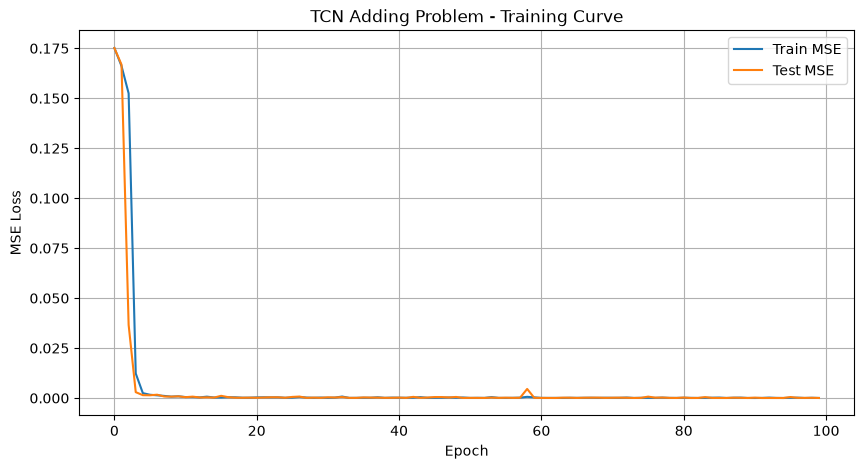

In [19]:
# Loss Curve

plt.figure(figsize=(10, 5))

plt.plot(
    train_losses,
    label="Train MSE"
)

plt.plot(
    test_losses,
    label="Test MSE"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("TCN Adding Problem - Training Curve")

plt.legend()
plt.grid(True)

plt.show()


## 15. 최종 테스트 결과 확인

학습이 끝난 후 Test 데이터에서 여러 샘플을 직접 확인합니다.

모델이 제대로 학습되었다면:

```text
실제 정답 ≈ 모델 예측
```

이 되어야 합니다.


In [20]:
# 최종 테스트 샘플 확인

model.eval()

with torch.no_grad():

    data, target = next(iter(test_loader))

    data = data.to(device)
    target = target.to(device)

    output = model(data)

print_samples(
    "Final Test",
    data,
    target,
    output,
    num_samples=10
)



--- [Final Test Phase] 결과 샘플 미리보기 ---
Sample 1:
  - 인덱스: 8, 54
  - 실제 값: 0.1151 + 0.0562
  - 실제 정답: 0.1713
  - 모델 예측: 0.1583 (오차: 0.0130)
Sample 2:
  - 인덱스: 130, 198
  - 실제 값: 0.4434 + 0.4768
  - 실제 정답: 0.9202
  - 모델 예측: 0.9131 (오차: 0.0070)
Sample 3:
  - 인덱스: 23, 105
  - 실제 값: 0.5931 + 0.4896
  - 실제 정답: 1.0827
  - 모델 예측: 1.0789 (오차: 0.0038)
Sample 4:
  - 인덱스: 67, 70
  - 실제 값: 0.7528 + 0.5665
  - 실제 정답: 1.3193
  - 모델 예측: 1.3186 (오차: 0.0007)
Sample 5:
  - 인덱스: 137, 151
  - 실제 값: 0.7602 + 0.1104
  - 실제 정답: 0.8706
  - 모델 예측: 0.8756 (오차: 0.0051)
Sample 6:
  - 인덱스: 4, 197
  - 실제 값: 0.6694 + 0.8544
  - 실제 정답: 1.5237
  - 모델 예측: 1.5245 (오차: 0.0008)
Sample 7:
  - 인덱스: 121, 132
  - 실제 값: 0.3445 + 0.7289
  - 실제 정답: 1.0734
  - 모델 예측: 1.0707 (오차: 0.0027)
Sample 8:
  - 인덱스: 41, 65
  - 실제 값: 0.5208 + 0.2517
  - 실제 정답: 0.7725
  - 모델 예측: 0.7634 (오차: 0.0091)
Sample 9:
  - 인덱스: 56, 130
  - 실제 값: 0.2873 + 0.5742
  - 실제 정답: 0.8614
  - 모델 예측: 0.8549 (오차: 0.0065)
Sample 10:
  - 인덱스: 39, 197
  - 실제 값: 0.0729 

## 16. 실제값 vs 예측값

모델의 회귀 성능을 직관적으로 확인하기 위해 실제값과 예측값을 scatter plot으로 표시합니다.

완벽한 모델이라면 모든 점이 다음 직선에 가까워집니다.

```text
Prediction = Target
```


In [21]:
# Test 전체 데이터에 대한 prediction 수집

model.eval()

all_targets = []
all_predictions = []

with torch.no_grad():

    for data, target in test_loader:

        data = data.to(device)

        output = model(data)

        all_targets.append(
            target.numpy()
        )

        all_predictions.append(
            output.cpu().numpy()
        )

all_targets = np.concatenate(
    all_targets
).reshape(-1)

all_predictions = np.concatenate(
    all_predictions
).reshape(-1)

print("Number of test samples:", len(all_targets))


Number of test samples: 2000


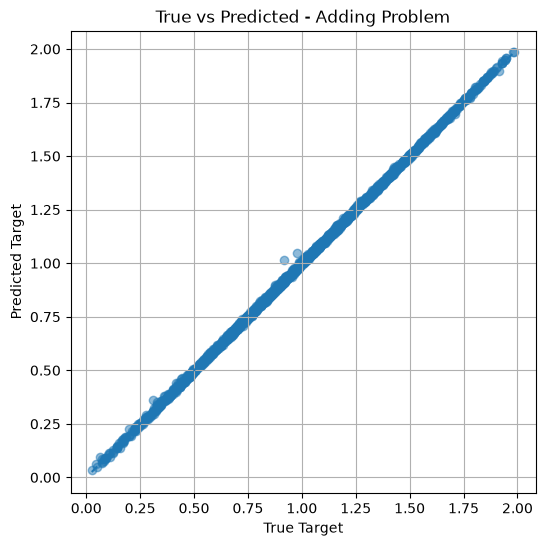

In [22]:
# 실제값 vs 예측값

plt.figure(figsize=(6, 6))

plt.scatter(
    all_targets,
    all_predictions,
    alpha=0.5
)

# 이상적인 Prediction = Target 직선
min_value = min(
    all_targets.min(),
    all_predictions.min()
)

max_value = max(
    all_targets.max(),
    all_predictions.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("True Target")
plt.ylabel("Predicted Target")

plt.title(
    "True vs Predicted - Adding Problem"
)

plt.grid(True)

plt.show()


## 17. MAE와 RMSE 추가 평가

MSE만 보는 것보다 실제 오차 크기를 직관적으로 보기 위해 MAE와 RMSE도 계산합니다.

### MAE

```text
MAE = |Target - Prediction|의 평균
```

### RMSE

```text
RMSE = sqrt(MSE)
```

RMSE는 MAE보다 큰 오차에 더 민감합니다.


In [23]:
# MAE / RMSE 계산

errors = all_targets - all_predictions

mae = np.mean(
    np.abs(errors)
)

rmse = np.sqrt(
    np.mean(errors ** 2)
)

mse = np.mean(
    errors ** 2
)

print(f"MSE :  {mse:.6f}")
print(f"MAE :  {mae:.6f}")
print(f"RMSE:  {rmse:.6f}")


MSE :  0.000047
MAE :  0.005033
RMSE:  0.006864


# 18. 핵심 정리

이번 실습에서 구현한 TCN의 핵심 흐름은 다음과 같습니다.

```text
Adding Problem
      │
      ▼
[Batch, 2, 200]
      │
      ▼
TemporalBlock
  dilation=1
      │
      ▼
TemporalBlock
  dilation=2
      │
      ▼
TemporalBlock
  dilation=4
      │
      ▼
...
      │
      ▼
TemporalBlock
  dilation=128
      │
      ▼
[Batch, 24, 200]
      │
      ▼
마지막 Time Step
      │
      ▼
Linear
      │
      ▼
예측값 [Batch, 1]
```

## 가장 중요한 개념

### ① TCN은 시간축에 Conv1d를 적용

RNN처럼 한 시점씩 순차적으로 처리하지 않고 convolution을 이용해 병렬적으로 처리합니다.

### ② Dilation이 증가하면서 시간 범위가 빠르게 증가

```text
1 → 2 → 4 → 8 → 16 → 32 → 64 → 128
```

따라서 긴 시퀀스에서도 과거의 정보를 효율적으로 활용할 수 있습니다.

### ③ Residual Connection

각 block에서

```text
Output = ReLU(TCN(x) + Residual(x))
```

형태로 입력을 직접 전달합니다.

### ④ Chomp1d

padding 때문에 미래 정보가 섞이는 것을 방지하기 위해 오른쪽 padding을 제거합니다.

### ⑤ Adding Problem은 회귀 문제

따라서 마지막 출력에 `softmax`를 사용하지 않고 Linear 출력값을 그대로 사용하며, `MSELoss`로 학습합니다.


# 19. 실습 과제

## 과제 1 — Kernel Size 변경

다음 값을 변경하고 성능을 비교해 보세요.

```python
kernel_size = 2
kernel_size = 3
kernel_size = 5
```

Receptive Field가 어떻게 달라지는지 계산해 보세요.

---

## 과제 2 — TCN 깊이 변경

다음과 같이 block 개수를 변경해 보세요.

```python
num_channels = [24, 24, 24, 24]
```

그리고

```python
num_channels = [24, 24, 24, 24, 24, 24, 24, 24]
```

두 모델의 성능을 비교해 보세요.

---

## 과제 3 — Dropout 실험

```python
dropout = 0.0
dropout = 0.2
dropout = 0.5
```

학습 curve가 어떻게 달라지는지 확인하세요.

---

## 과제 4 — Sequence Length 변경

```python
seq_length = 100
seq_length = 200
seq_length = 400
```

Sequence Length가 증가했을 때 현재 TCN의 Receptive Field가 충분한지 확인하세요.

---

## 과제 5 — Dilated Convolution 제거

`dilation_size = 2 ** i`를 사용하지 않고 모든 block에서

```python
dilation = 1
```

을 사용하도록 변경해 보세요.

그 후 Adding Problem 성능이 어떻게 변하는지 비교해 보면 **dilation이 장기 의존성(long-range dependency)을 처리하는 데 왜 중요한지** 직접 확인할 수 있습니다.
